In [1]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import time

%matplotlib inline
import functools
import sys

import jax
from jax import config

config.update("jax_enable_x64", True)


import jax.numpy as jnp

os.getcwd()
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../../"))

In [2]:
from yancc.field import Field
from yancc.solve import solve_mdke
from yancc.velocity_grids import UniformPitchAngleGrid

In [3]:
configs = {
    "W7X-KJM": {
        "dat_path": "./Benchmark-MONKES-JAX/W7X-KJM/monkes_Monoenergetic_Database.dat",
        "booz_path": "./Benchmark-MONKES-JAX/W7X-KJM/boozmn_KJM.nc",
        "s": 0.204,
        "K11": 3.7969,
        "K13": 1.9486,
        "K31": 1.9486,
        "K33": 1.0,
        "B0": 2.50033351674266,
    },
}


def read_monkes_dat(path):
    data = np.loadtxt(path, skiprows=1)
    nuhat = data[:, 0]
    erhat = data[:, 1]
    nt = data[:, 2].astype(int)
    nz = data[:, 3].astype(int)
    nl = data[:, 4].astype(int)
    d11 = data[:, 5]
    d31 = data[:, 6]
    d13 = data[:, 7]
    d33 = data[:, 8]
    d33s = data[:, 9]
    walltime = data[:, 10]
    cputime = data[:, 11]

    data = {
        "nuhat": nuhat,
        "erhat": erhat,
        "nt": nt,
        "nz": nz,
        "nl": nl,
        "D11": d11,
        "D31": d31,
        "D13": d13,
        "D33": d33,
        "D33_spitzer": d33s,
        "wall time": walltime,
        "cpu time": cputime,
    }
    return data

In [4]:
config = configs["W7X-KJM"]
monkes_data = read_monkes_dat(config["dat_path"])

In [5]:
monkes_data["wall time"]

array([52.4734, 52.0728, 52.943 , 53.5766, 54.0777, 53.5251, 53.4086,
       54.2891, 52.4376, 53.3553, 51.93  , 53.1801, 53.3354, 56.3884,
       54.0111, 53.5414, 53.4622, 53.6081, 55.9919, 56.1607, 53.6359,
       53.3575, 53.4693, 52.0717, 53.7463, 51.9026, 52.7034, 53.4697,
       53.6082, 52.7835, 54.6915, 53.1479, 53.3801, 53.1318, 52.2383,
       53.8547, 53.4695, 53.0692, 52.7078, 52.9712, 52.8093, 53.6066])

In [6]:
np.sqrt(config["s"])

np.float64(0.45166359162544856)

In [7]:
monkes_data["nuhat"]

array([1.e-05, 3.e-05, 1.e-04, 3.e-04, 1.e-03, 3.e-03, 1.e-02, 3.e-02,
       1.e-01, 3.e-01, 1.e+00, 3.e+00, 1.e+01, 3.e+01, 1.e-05, 3.e-05,
       1.e-04, 3.e-04, 1.e-03, 3.e-03, 1.e-02, 3.e-02, 1.e-01, 3.e-01,
       1.e+00, 3.e+00, 1.e+01, 3.e+01, 1.e-05, 3.e-05, 1.e-04, 3.e-04,
       1.e-03, 3.e-03, 1.e-02, 3.e-02, 1.e-01, 3.e-01, 1.e+00, 3.e+00,
       1.e+01, 3.e+01])

In [8]:
print(monkes_data["nl"][0], monkes_data["nt"][0], monkes_data["nz"][0])

180 39 99


In [9]:
nt = 31
nz = 81
na = 201

field = Field.from_booz_xform(
    config["booz_path"], np.sqrt(config["s"]), nt, nz, cutoff=1e-5
)
pitchgrid = UniformPitchAngleGrid(na)

In [34]:
solve_mdke_jit = jax.jit(
    functools.partial(solve_mdke, verbose=2, multigrid_options={"cycle_index": 3})
)

solve_mdke_compiled = (
    solve_mdke_jit.trace(
        field,
        pitchgrid,
        jnp.array(0.0),
        jnp.array(1e-2),
        rtol=jnp.array(1e-7),
    )
    .lower()
    .compile()
)

In [35]:
print(solve_mdke_compiled.cost_analysis())

{'utilization36{}': 94.0, 'utilization168{}': 44.0, 'utilization333{}': 16.0, 'utilization230{}': 24.0, 'utilization97{}': 80.0, 'utilization77{}': 88.0, 'utilization201{}': 28.0, 'utilization258{}': 16.0, 'utilization94{}': 80.0, 'utilization320{}': 16.0, 'utilization307{}': 16.0, 'utilization243{}': 16.0, 'utilization86{}': 88.0, 'utilization315{}': 16.0, 'utilization174{}': 44.0, 'utilization52{}': 88.0, 'utilization229{}': 24.0, 'bytes accessed26{}': 13.0, 'utilization377{}': 2.0, 'utilization314{}': 16.0, 'utilization159{}': 44.0, 'utilization344{}': 16.0, 'utilization208{}': 28.0, 'utilization153{}': 44.0, 'utilization6{}': 614.0, 'utilization376{}': 2.0, 'utilization226{}': 24.0, 'utilization359{}': 6.0, 'utilization328{}': 16.0, 'utilization259{}': 16.0, 'utilization20{}': 113.0, 'bytes accessedout{1}': 1338728192.0, 'utilization112{}': 76.0, 'utilization342{}': 16.0, 'utilization178{}': 44.0, 'utilization66{}': 88.0, 'utilization126{}': 76.0, 'utilization321{}': 16.0, 'utiliza

In [36]:
print(solve_mdke_compiled.memory_analysis())

CompiledMemoryStats(generated_code_size_in_bytes=3820778, argument_size_in_bytes=207628, output_size_in_bytes=185941702, alias_size_in_bytes=0, temp_size_in_bytes=3998287592, host_generated_code_size_in_bytes=0, host_argument_size_in_bytes=0, host_output_size_in_bytes=0, host_alias_size_in_bytes=0, host_temp_size_in_bytes=0)


In [37]:
print(solve_mdke_compiled.memory_analysis().temp_size_in_bytes / 1e9)

3.998287592


In [38]:
data_yancc = {}
data_yancc["nuhat"] = monkes_data["nuhat"]
data_yancc["erhat"] = monkes_data["erhat"]
data_yancc["D11"] = np.array([])
data_yancc["D13"] = np.array([])
data_yancc["D31"] = np.array([])
data_yancc["D33"] = np.array([])
data_yancc["wall time"] = np.array([])
data_yancc["sols"] = []
data_yancc["infos"] = []

for i in range(len(data_yancc["nuhat"])):
    nuhat = data_yancc["nuhat"][i]
    erhat = data_yancc["erhat"][i]
    print(
        f"Running i={i}, nuhat={nuhat:.3e}, erhat={erhat:.3e}, nt={nt}, nz={nz}, na={na}"
    )
    t1 = time.perf_counter()

    sol, info = jax.block_until_ready(
        solve_mdke_compiled(
            field,
            pitchgrid,
            erhat * field.a_minor,
            nuhat,
            rtol=1e-7,
        )
    )

    Dij = sol.get("Dij_DKES")
    t2 = time.perf_counter()
    print(f"Took {t2 - t1:.3e} s")
    del info["U1"]
    del info["U2"]
    del info["C1"]
    del info["C2"]
    data_yancc["D11"] = np.append(data_yancc["D11"], Dij[0, 0])
    data_yancc["D31"] = np.append(data_yancc["D31"], Dij[2, 0])
    data_yancc["D13"] = np.append(data_yancc["D13"], Dij[0, 2])
    data_yancc["D33"] = np.append(data_yancc["D33"], Dij[2, 2])
    data_yancc["wall time"] = np.append(data_yancc["wall time"], t2 - t1)
    data_yancc["sols"].append(sol)
    data_yancc["infos"].append(info)

Running i=0, nuhat=1.000e-05, erhat=0.000e+00, nt=31, nz=81, na=201
Field info (source: booz_xform):
    ρ         =  0.452              ι         = -8.788e-01
    <B>       =  2.471e+00 T        δ_B       =  7.738e-02
    Bmax/Bmin =  1.323e+00          f_trapped =  5.343e-01
    I         = -1.984e-17 T·m      G         =  1.440e+01 T·m
ν` =  1.000e-05
E` =  0.000e+00
Grid 0: nα=  50, nθ=   8, nζ=  20, N=8,000
Grid 1: nα= 101, nθ=  16, nζ=  41, N=66,256
Grid 2: nα= 201, nθ=  31, nζ=  81, N=504,711
GCROT  iter=  0   res=1.000e+00
    FGMRES  iter=  0   res=2.379e-01
    FGMRES  iter= 10   res=7.351e-02
    FGMRES  iter= 20   res=1.573e-02
    FGMRES  iter= 30   res=4.310e-03
    FGMRES  iter= 40   res=1.303e-03
    FGMRES  iter= 50   res=2.717e-04
    FGMRES  iter= 60   res=5.615e-05
    FGMRES  iter= 70   res=1.026e-05
    FGMRES  iter= 80   res=1.412e-06
    FGMRES  iter= 90   res=1.559e-07
GCROT  iter=  1   res=9.945e-08
GCROT  iter=  0   res=1.000e+00
    FGMRES  iter=  0   res=9.

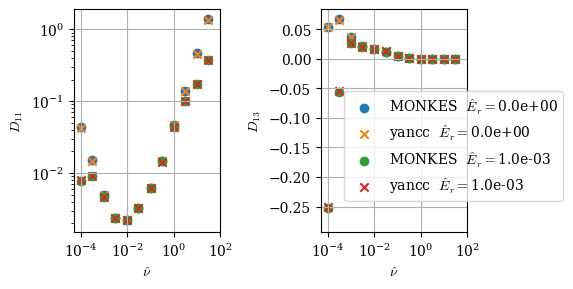

In [118]:
from matplotlib import rcParams

matplotlib.rcdefaults()
rcParams["font.family"] = "DejaVu Serif"
rcParams["mathtext.fontset"] = "cm"
rcParams["font.size"] = 10
rcParams["figure.facecolor"] = (1, 1, 1, 1)
rcParams["figure.figsize"] = (6, 4)
rcParams["lines.markersize"] = 6
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 10


def plot_coefficients(data, ax, ir=0, marker="o", tag=""):
    er = np.unique(data["erhat"])[ir]
    idx = np.where(data["erhat"] == er)
    ax[0, 0].scatter(
        data["nuhat"][idx],
        data["D11"][idx],
        marker=marker,
    )
    ax[0, 0].set_xscale("log")
    ax[0, 0].set_yscale("log")
    ax[0, 0].set_ylabel("$D_{11}$")
    ax[0, 0].set_xlabel("$\\hat{\\nu}$")

    ax[0, 1].scatter(
        data["nuhat"][idx],
        data["D13"][idx],
        label=tag + "  $\\hat{E}_r = $" + f"{er:.1e}",
        marker=marker,
    )
    ax[0, 1].set_xscale("log")
    ax[0, 1].set_ylabel("$D_{13}$")
    ax[0, 1].set_xlabel("$\\hat{\\nu}$")

    return ax


fig, ax = plt.subplots(1, 2, figsize=(5, 3), squeeze=False)
for ir in [0, 2]:
    ax = plot_coefficients(monkes_data, ax, ir=ir, marker="o", tag="MONKES")
    ax = plot_coefficients(data_yancc, ax, ir=ir, marker="x", tag="yancc")
for a in ax.flat:
    # monkes is only converged to within 5% at lowest collisionality
    # so we truncate to where both codes are converged to within 1%
    a.set_xlim(5e-5, 1e2)
    a.set_xticks(np.logspace(-4, 2, 4))
    a.grid(True)
fig.legend(bbox_to_anchor=(0.65, 0.2, 0.5, 0.5), ncols=1)
fig.set_tight_layout(True)
# plt.subplots_adjust(left=0.1, right=1.5, bottom=0.1, top=0.9)

In [119]:
fig.savefig("benchmark_mdke_Dij.pdf", bbox_inches="tight")
fig.savefig("benchmark_mdke_Dij.png", bbox_inches="tight")

In [74]:
from monkes.monkes import Field as MonkesField
from monkes.monkes import solve_mdke_normalized

In [75]:
monkes_field = MonkesField.from_booz_xform(
    config["booz_path"],
    config["s"],
    monkes_data["nt"][0],
    monkes_data["nz"][0],
    cutoff=1e-5,
)

In [76]:
solve_mdke_normalized_jit = jax.jit(
    functools.partial(
        solve_mdke_normalized,
        lazy=True,
        nl=monkes_data["nl"][0],
    )
)

solve_mdke_normalized_compiled = (
    solve_mdke_normalized_jit.trace(
        monkes_field,
        jnp.array(1e-2),
        jnp.array(0.0),
    )
    .lower()
    .compile()
)

/global/u2/w/wconlin/monkes/monkes/_core.py:125: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  operator = MonoenergeticDKOperator(field, nl, Erhat, nuhat)


In [77]:
print(solve_mdke_normalized_compiled.cost_analysis())

{'utilization18{}': 2.0, 'bytes accessedout{3}': 30896.0, 'utilization17{}': 2.0, 'utilization14{}': 3.0, 'utilization4{}': 29.0, 'utilization13{}': 3.0, 'utilization12{}': 3.0, 'utilization2{}': 53.0, 'bytes accessedout{4}': 30896.0, 'flops': 8875653120.0, 'bytes accessed0{}': 7695716864.0, 'utilization5{}': 16.0, 'utilization1{}': 151.0, 'bytes accessedout{}': 7804094976.0, 'bytes accessed5{}': 238578928.0, 'utilization0{}': 392.0, 'utilization11{}': 3.0, 'utilization8{}': 6.0, 'utilization15{}': 2.0, 'bytes accessed8{}': 8.0, 'bytes accessed6{}': 92672.0, 'utilization16{}': 2.0, 'bytes accessedout{2}': 61784.0, 'bytes accessed3{}': 238656288.0, 'optimal_seconds': -13.0, 'bytes accessed1{}': 1568217856.0, 'bytes accessedout{0}': 715968448.0, 'bytes accessed7{}': 8.0, 'bytes accessed2{}': 239033072.0, 'bytes accessedout{1}': 715968448.0, 'utilization6{}': 12.0, 'utilization7{}': 7.0, 'utilization9{}': 5.0, 'bytes accessedout{5}': 30896.0, 'bytes accessed4{}': 140512.0, 'utilization10{

In [78]:
print(solve_mdke_normalized_compiled.memory_analysis())

CompiledMemoryStats(generated_code_size_in_bytes=234236, argument_size_in_bytes=247144, output_size_in_bytes=33359136, alias_size_in_bytes=0, temp_size_in_bytes=1432181400, host_generated_code_size_in_bytes=0, host_argument_size_in_bytes=0, host_output_size_in_bytes=0, host_alias_size_in_bytes=0, host_temp_size_in_bytes=0)


In [79]:
print(solve_mdke_normalized_compiled.memory_analysis().temp_size_in_bytes / 1e9)

1.4321814


In [80]:
monkes_jax_times = []

for i in range(len(monkes_data["nuhat"])):
    nuhat = monkes_data["nuhat"][i]
    erhat = monkes_data["erhat"][i]
    print(f"Running i={i}, nuhat={nuhat:.3e}, erhat={erhat:.3e}")
    t1 = time.perf_counter()

    # we're just running this to get timing info, don't care about result
    _ = jax.block_until_ready(
        solve_mdke_normalized_compiled(
            monkes_field,
            nuhat,
            erhat * monkes_field.a_minor,
        )
    )

    t2 = time.perf_counter()
    print(f"Took {t2 - t1:.3e} s")
    monkes_jax_times.append(t2 - t1)

Running i=0, nuhat=1.000e-05, erhat=0.000e+00
Took 8.333e+00 s
Running i=1, nuhat=3.000e-05, erhat=0.000e+00
Took 8.235e+00 s
Running i=2, nuhat=1.000e-04, erhat=0.000e+00
Took 8.234e+00 s
Running i=3, nuhat=3.000e-04, erhat=0.000e+00
Took 8.234e+00 s
Running i=4, nuhat=1.000e-03, erhat=0.000e+00
Took 8.233e+00 s
Running i=5, nuhat=3.000e-03, erhat=0.000e+00
Took 8.233e+00 s
Running i=6, nuhat=1.000e-02, erhat=0.000e+00
Took 8.233e+00 s
Running i=7, nuhat=3.000e-02, erhat=0.000e+00
Took 8.232e+00 s
Running i=8, nuhat=1.000e-01, erhat=0.000e+00
Took 8.232e+00 s
Running i=9, nuhat=3.000e-01, erhat=0.000e+00
Took 8.233e+00 s
Running i=10, nuhat=1.000e+00, erhat=0.000e+00
Took 8.232e+00 s
Running i=11, nuhat=3.000e+00, erhat=0.000e+00
Took 8.232e+00 s
Running i=12, nuhat=1.000e+01, erhat=0.000e+00
Took 8.233e+00 s
Running i=13, nuhat=3.000e+01, erhat=0.000e+00
Took 8.232e+00 s
Running i=14, nuhat=1.000e-05, erhat=1.000e-04
Took 8.233e+00 s
Running i=15, nuhat=3.000e-05, erhat=1.000e-04
Too

In [83]:
monkes_jax_times = np.array(monkes_jax_times)

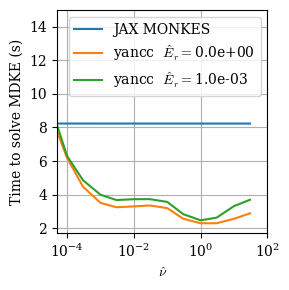

In [125]:
def plot_times(data, times, ax, ir=0, tag="", include_Er=True):
    er = np.unique(data["erhat"])[ir]
    idx = np.where(data["erhat"] == er)
    ax[0, 0].plot(
        data["nuhat"][idx],
        times[idx],
        label=tag + ("  $\\hat{E}_r = $" + f"{er:.1e}" if include_Er else ""),
    )
    ax[0, 0].set_xscale("log")
    ax[0, 0].set_ylabel("Time to solve MDKE (s)")
    ax[0, 0].set_xlabel("$\\hat{\\nu}$")

    return ax


fig, ax = plt.subplots(1, 1, figsize=(3, 3), squeeze=False)
ax = plot_times(
    monkes_data, monkes_jax_times, ax, ir=0, tag="JAX MONKES", include_Er=False
)
for ir in [0, 2]:
    ax = plot_times(data_yancc, data_yancc["wall time"], ax, ir=ir, tag="yancc")
for a in ax.flat:
    a.set_xlim(5e-5, 1e2)
    a.set_xticks(np.logspace(-4, 2, 4))
    a.grid(True)
ax[0, 0].legend(loc="best", ncols=1)
fig.set_tight_layout(True)

In [126]:
fig.savefig("benchmark_mdke_time.pdf", bbox_inches="tight")
fig.savefig("benchmark_mdke_time.png", bbox_inches="tight")